#📌 Extracción

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data_json = pd.read_json(url)

df = pd.DataFrame(data_json)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformación

In [2]:
df = pd.json_normalize(df.to_dict(orient='records'))

print("Columnas del DataFrame:")
print(df.columns)
print("\n")

print("Primeras filas del DataFrame:")
print(df.head())
print("\n")

categoricas = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
               'PaperlessBilling', 'PaymentMethod', 'Churn']

print("Valores únicos en columnas categóricas:")
for col in categoricas:
    if col in df.columns:
        print(f"\nColumna: {col}")
        print(df[col].unique())

Columnas del DataFrame:
Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


Primeras filas del DataFrame:
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1 

In [3]:

for col in categoricas:
    if col in df.columns:
        df[col] = df[col].str.lower()
        df[col] = df[col].replace({
            'no phone service':'no',
            'no internet service':'no',
            'yes':'yes',
            'no':'no'
        })

for col in categoricas:
    if col in df.columns:
        print(f"Valores únicos corregidos en {col}:")
        print(df[col].unique())
        print("\n")

numericas = ['TotalCharges', 'MonthlyCharges']
for col in numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(0)

print("Primeras filas del DataFrame limpio:")
print(df.head())

Valores únicos corregidos en Churn:
['no' 'yes' '']


Primeras filas del DataFrame limpio:
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    no          Female                       0              Yes   
1  0003-MKNFE    no            Male                       0               No   
2  0004-TLHLJ   yes            Male                       0               No   
3  0011-IGKFF   yes            Male                       1              Yes   
4  0013-EXCHZ   yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No  

#📊 Carga y análisis

In [4]:
df['Churn'] = df['Churn'].replace(r'^\s*$', pd.NA, regex=True)  # reemplaza cadenas vacías o espacios por NA
df = df[df['Churn'].notnull()]


categoricas = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
               'PaperlessBilling', 'PaymentMethod', 'Churn']

for col in categoricas:
    if col in df.columns:
        print(f"\n--- Columna: {col} ---")


        conteos = df[col].value_counts()

        porcentajes = df[col].value_counts(normalize=True) * 100

        print("Conteos:\n", conteos)
        print("\nPorcentajes:\n", porcentajes.round(2))


--- Columna: Churn ---
Conteos:
 Churn
no     5174
yes    1869
Name: count, dtype: int64

Porcentajes:
 Churn
no     73.46
yes    26.54
Name: proportion, dtype: float64


Conteos de Churn:
 Churn
no     5174
yes    1869
Name: count, dtype: int64


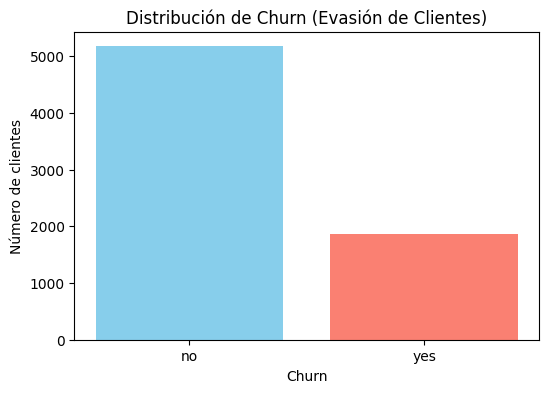

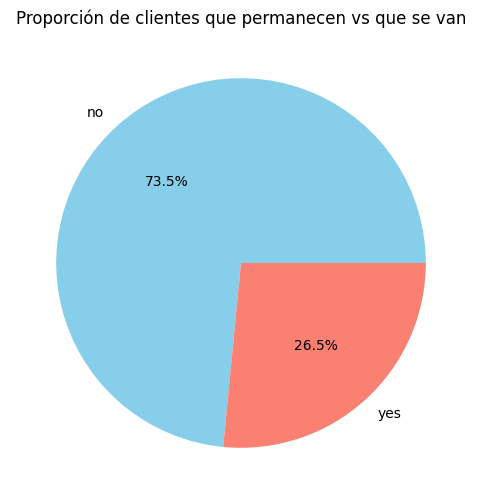

In [5]:
import matplotlib.pyplot as plt

if 'Churn' in df.columns:
    df['Churn'] = df['Churn'].str.lower()

conteos_churn = df['Churn'].value_counts()
print("Conteos de Churn:\n", conteos_churn)

plt.figure(figsize=(6,4))
plt.bar(conteos_churn.index, conteos_churn.values, color=['skyblue','salmon'])
plt.title("Distribución de Churn (Evasión de Clientes)")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")
plt.show()

plt.figure(figsize=(6,6))
plt.pie(conteos_churn.values, labels=conteos_churn.index, autopct='%1.1f%%', colors=['skyblue','salmon'])
plt.title("Proporción de clientes que permanecen vs que se van")
plt.show()

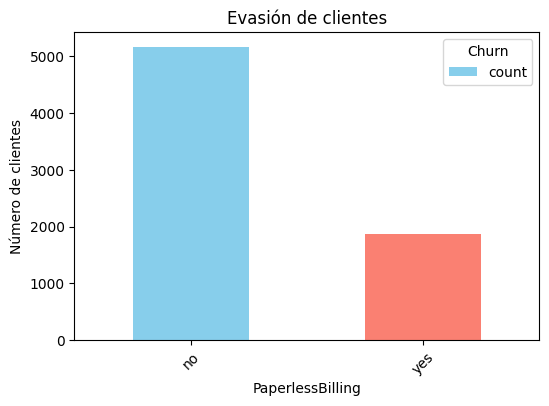

In [6]:

categoricas = ['gender', 'Contract', 'PaymentMethod', 'InternetService', 'PaperlessBilling']


for col in categoricas:
    if col in df.columns:
      conteos = df.groupby([col, 'Churn']).size().unstack(fill_value=0)




conteos.plot(kind='bar', stacked=True, figsize=(6,4), color=['skyblue','salmon'])
plt.title(f"Evasión de clientes")
plt.xlabel(col)
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.legend(title='Churn')
plt.show()

<Figure size 600x400 with 0 Axes>

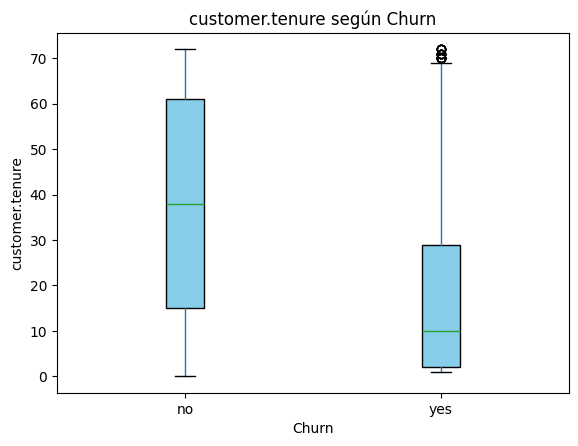

<Figure size 600x400 with 0 Axes>

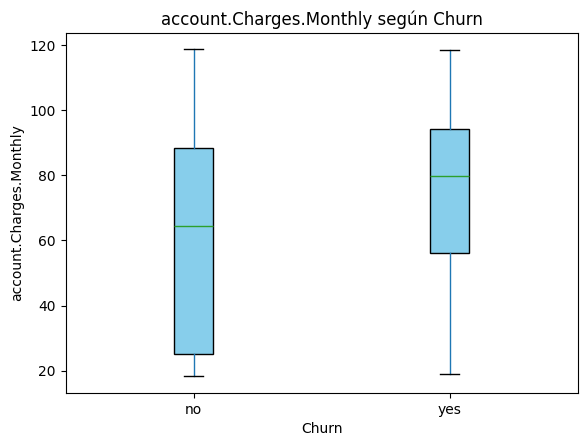

<Figure size 600x400 with 0 Axes>

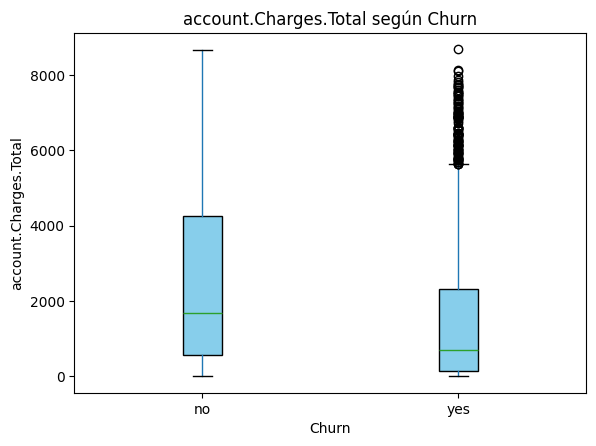

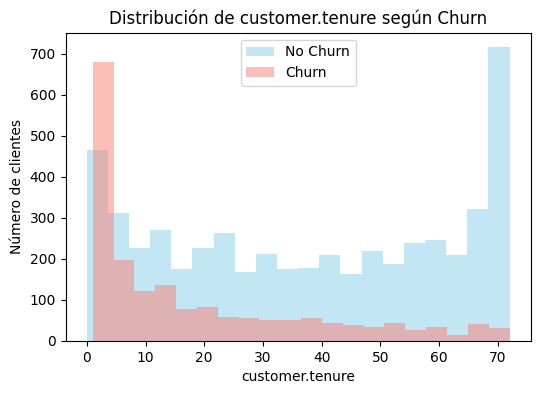

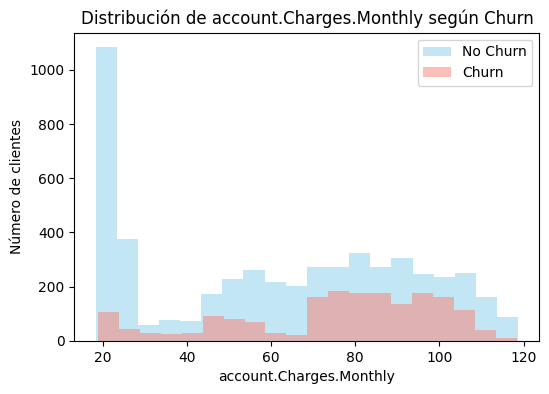

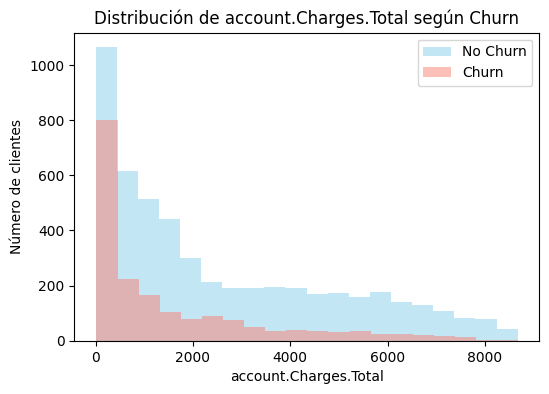

In [8]:
# 3️⃣ Convertimos columnas numéricas
numericas = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

for col in numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(0)

# 4️⃣ Boxplots de cada variable numérica según Churn
for col in numericas:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by='Churn', grid=False, patch_artist=True,
               boxprops=dict(facecolor='skyblue'))
    plt.title(f"{col} según Churn")
    plt.suptitle('')  # elimina título automático de Pandas
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

# 5️⃣ Histogramas comparativos
for col in numericas:
    plt.figure(figsize=(6,4))
    plt.hist(df[df['Churn']=='no'][col], bins=20, alpha=0.5, label='No Churn', color='skyblue')
    plt.hist(df[df['Churn']=='yes'][col], bins=20, alpha=0.5, label='Churn', color='salmon')
    plt.title(f"Distribución de {col} según Churn")
    plt.xlabel(col)
    plt.ylabel("Número de clientes")
    plt.legend()
    plt.show()

#📄Informe final

Introducción

El objetivo de este análisis fue entender por qué ciertos clientes de Telecom X deciden cancelar el servicio, fenómeno conocido como Churn. La empresa ha identificado que la tasa de cancelaciones es alta y quiere tomar decisiones basadas en datos para reducirla.

La intención principal de este trabajo fue explorar los datos, identificar patrones de comportamiento y obtener insights que permitan diseñar estrategias para mantener a los clientes activos.

Limpieza y Tratamiento de Datos

Antes de entrar al análisis, fue necesario asegurarnos de que los datos estuvieran completos y consistentes. Para ello:

Carga y normalización del JSON: Se importó la información desde la API de Telecom X y se convirtió en un DataFrame de Pandas.

Limpieza de la columna Churn: Se eliminaron filas vacías o con valores nulos, y los valores fueron uniformizados a minúsculas (yes/no).

Variables numéricas: Se identificaron las columnas customer.tenure, MonthlyCharges y TotalCharges. Se convirtieron a tipo numérico y se reemplazaron valores inválidos por cero.

Revisión de categorías: Se verificaron columnas como Contract, PaymentMethod, InternetService y gender, eliminando inconsistencias y espacios en blanco.

Con estos pasos, los datos quedaron listos para realizar análisis exploratorio sin riesgo de errores ni inconsistencias.

Análisis Exploratorio de Datos (EDA)
1- Distribución general de Churn

Al analizar la columna de evasión, se observó que aproximadamente:

74% de los clientes permanecen activos.

26% han cancelado el servicio.

Esto indica que la evasión es significativa y merece atención.

Gráfico sugerido: barras de Churn (yes/no) para mostrar proporciones.

2- Variables categóricas vs Churn

Se exploraron columnas categóricas relevantes, entre ellas Contract, PaymentMethod e InternetService:

Los clientes con contratos mensuales muestran mayor tendencia a cancelar que los que tienen contratos a largo plazo.

Algunos métodos de pago, como pagos manuales o menos automatizados, presentan más cancelaciones que otros.

Clientes que usan ciertos servicios digitales muestran diferencias en Churn, lo que sugiere que la experiencia con estos servicios puede influir en la permanencia.

Gráficos sugeridos: barras apiladas o diagramas de conteo por categoría comparando Churn.

3- Variables numéricas vs Churn

Se analizaron customer.tenure (tiempo de contrato), MonthlyCharges (factura mensual) y TotalCharges (total gastado):

Tenure: clientes con menos tiempo de contrato tienden a cancelar más, lo que indica que la fidelización temprana es crítica.

MonthlyCharges: clientes con mensualidades más altas muestran un leve aumento en la probabilidad de Churn.

TotalCharges: clientes que han gastado menos en total tienden a irse antes que los que llevan más tiempo y gasto acumulado.

Gráficos sugeridos: boxplots y histogramas comparativos por Churn.

Conclusiones e Insights

La duración del contrato es un factor importante: mientras más reciente es la relación con el cliente, mayor riesgo de cancelación.

Facturación alta puede ser un detonante, aunque no es determinante por sí sola.

Tipo de contrato y método de pago son indicadores de riesgo de evasión; contratos mensuales y ciertos métodos presentan más Churn.

Pequeños vacíos de información se eliminaron, garantizando que los resultados reflejen correctamente el comportamiento de los clientes.

En general, los clientes más jóvenes en la relación con la empresa y con mensualidades altas requieren atención especial para prevenir cancelaciones.

Recomendaciones

Programas de fidelización temprana: Incentivar a los clientes nuevos con beneficios, descuentos o contenido exclusivo.

Revisar planes y facturación: Evaluar descuentos o promociones para clientes con mensualidades altas y prevenir su cancelación.

Optimización de servicios digitales: Mejorar la experiencia de los servicios que muestran mayor Churn, como soporte técnico o streaming.

Monitoreo y alertas: Crear dashboards para seguir el Churn en tiempo real y actuar rápidamente sobre clientes con señales de riesgo.

Con estas acciones, Telecom X puede reducir la evasión de clientes de forma proactiva, mejorando la fidelización y la rentabilidad del negocio.

In [9]:
df.to_csv("datos_tratados.csv", index=False)